                                               TASK 1 RESTAURANT REVIEWS ANALYSIS

In [1]:
# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter

In [3]:
# Load dataset

file_path = "Dataset .xlsx"
df = pd.read_excel(file_path)

print("Dataset Loaded Successfully!")
print("Total Number of Restaurants:", len(df))

# Display first 5 rows
df.head()

Dataset Loaded Successfully!
Total Number of Restaurants: 9551


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Check rating text column

print("Unique Rating Text Values:")
print(df['Rating text'].value_counts())

Unique Rating Text Values:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [7]:
# Convert to string
df['Rating text'] = df['Rating text'].astype(str)

# Create new column for review length
df['Review Length'] = df['Rating text'].apply(len)

print("Review Length Column Created Successfully!")
print("Average Review Length:", df['Review Length'].mean())

Review Length Column Created Successfully!
Average Review Length: 7.020730813527379


In [9]:
correlation = df['Review Length'].corr(df['Aggregate rating'])

print("Correlation Between Review Length and Rating:")
print(correlation)

Correlation Between Review Length and Rating:
-0.4788848381349329


In [11]:
# Combine all rating text
all_text = " ".join(df['Rating text']).lower()

# Remove special characters
all_text = re.sub(r'[^a-zA-Z ]', '', all_text)

# Split into words
words = all_text.split()

# Count word frequency
word_count = Counter(words)

print("Top 15 Most Common Words:")
print(word_count.most_common(15))

Top 15 Most Common Words:
[('average', 3737), ('good', 3179), ('not', 2148), ('rated', 2148), ('very', 1079), ('excellent', 301), ('poor', 186)]


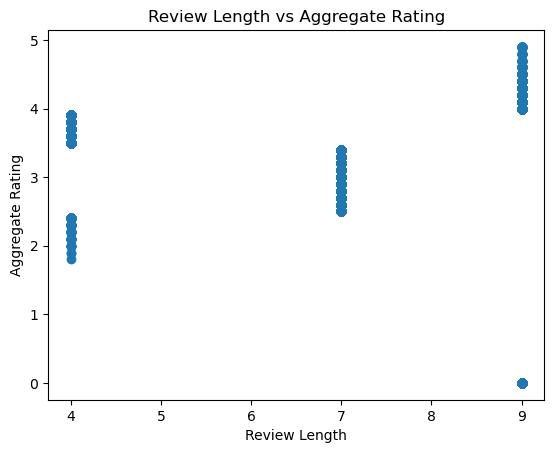

In [13]:
plt.figure()
plt.scatter(df['Review Length'], df['Aggregate rating'])
plt.title("Review Length vs Aggregate Rating")
plt.xlabel("Review Length")
plt.ylabel("Aggregate Rating")
plt.show()

                                                     TASK 2 VOTES ANALYSIS

In [15]:
print("Votes Column Info:")
print(df['Votes'].describe())

Votes Column Info:
count     9551.000000
mean       156.909748
std        430.169145
min          0.000000
25%          5.000000
50%         31.000000
75%        131.000000
max      10934.000000
Name: Votes, dtype: float64


In [17]:
highest_votes = df.loc[df['Votes'].idxmax()]

print("Restaurant with Highest Votes:")
print(highest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

Restaurant with Highest Votes:
Restaurant Name      Toit
Votes               10934
Aggregate rating      4.8
Name: 728, dtype: object


In [19]:
lowest_votes = df.loc[df['Votes'].idxmin()]

print("Restaurant with Lowest Votes:")
print(lowest_votes[['Restaurant Name', 'Votes', 'Aggregate rating']])

Restaurant with Lowest Votes:
Restaurant Name     Cantinho da Gula
Votes                              0
Aggregate rating                 0.0
Name: 69, dtype: object


In [21]:
vote_rating_corr = df['Votes'].corr(df['Aggregate rating'])

print("Correlation Between Votes and Rating:")
print(vote_rating_corr)

Correlation Between Votes and Rating:
0.31369058419541146


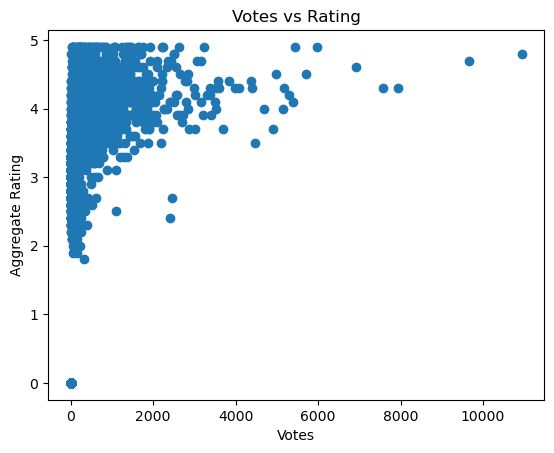

In [23]:
plt.figure()
plt.scatter(df['Votes'], df['Aggregate rating'])
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.show()

                                      TASK 3 PRICE RANGE vs ONLINE DELIVERY AND TABLE BOOKING

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
file_path = "Dataset .xlsx"
df = pd.read_excel(file_path)

print("Dataset Loaded Successfully!")
print("Total Restaurants:", len(df))

df.head()

Dataset Loaded Successfully!
Total Restaurants: 9551


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [29]:
print("Columns in Dataset:")
print(df.columns)

Columns in Dataset:
Index(['ï»¿Restaurant ID', 'Restaurant Name', 'Country Code', 'City',
       'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude',
       'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [31]:
price_distribution = df['Price range'].value_counts().sort_index()

print("Price Range Distribution:")
print(price_distribution)

Price Range Distribution:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64


In [33]:
price_online = pd.crosstab(df['Price range'], df['Has Online delivery'])

print("Price Range vs Online Delivery:")
print(price_online)

Price Range vs Online Delivery:
Has Online delivery    No   Yes
Price range                    
1                    3743   701
2                    1827  1286
3                     997   411
4                     533    53


In [35]:
price_online_percentage = price_online.div(price_online.sum(axis=1), axis=0) * 100

print("Online Delivery Percentage by Price Range:")
print(price_online_percentage)

Online Delivery Percentage by Price Range:
Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


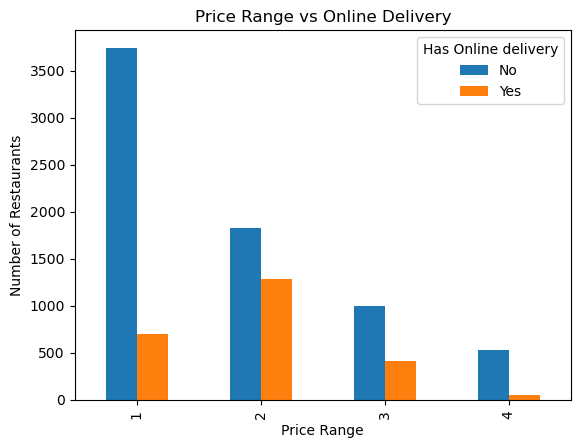

In [37]:
price_online.plot(kind='bar')
plt.title("Price Range vs Online Delivery")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

In [39]:
price_table = pd.crosstab(df['Price range'], df['Has Table booking'])

print("Price Range vs Table Booking:")
print(price_table)

Price Range vs Table Booking:
Has Table booking    No  Yes
Price range                 
1                  4443    1
2                  2874  239
3                   764  644
4                   312  274


In [41]:
price_table_percentage = price_table.div(price_table.sum(axis=1), axis=0) * 100

print("Table Booking Percentage by Price Range:")
print(price_table_percentage)

Table Booking Percentage by Price Range:
Has Table booking         No        Yes
Price range                            
1                  99.977498   0.022502
2                  92.322518   7.677482
3                  54.261364  45.738636
4                  53.242321  46.757679


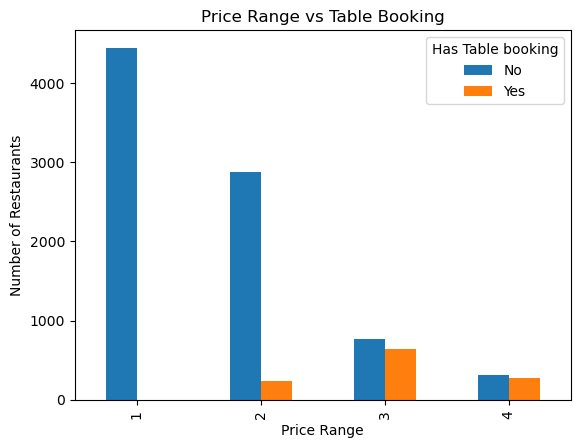

In [43]:
price_table.plot(kind='bar')
plt.title("Price Range vs Table Booking")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

In [45]:
service_percentage = df.groupby('Price range')[['Has Online delivery','Has Table booking']].apply(
    lambda x: (x == 'Yes').mean() * 100
)

print("Service Percentage by Price Range:")
print(service_percentage)

Service Percentage by Price Range:
             Has Online delivery  Has Table booking
Price range                                        
1                      15.774077           0.022502
2                      41.310633           7.677482
3                      29.190341          45.738636
4                       9.044369          46.757679
